# C — Visualizations (fully executable)

This notebook generates the required figures directly from the processed data.

All plots are saved into `figures/` with the expected names `fig01` through `fig12`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(PROCESSED / "master_train.csv")
weather = pd.read_csv(PROCESSED / "cleaned_weather.csv")
prices = pd.read_csv(PROCESSED / "cleaned_prices.csv")

analysis = train.merge(
    prices.rename(columns={"year":"survey_year"}),
    on=["region","crop_type","survey_year"],
    how="left",
    validate="many_to_one"
)
analysis["revenue_birr_ha"] = (
    analysis["yield_tons_per_ha"] * 10 * analysis["price_birr_per_quintal"]
)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGURES / name, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

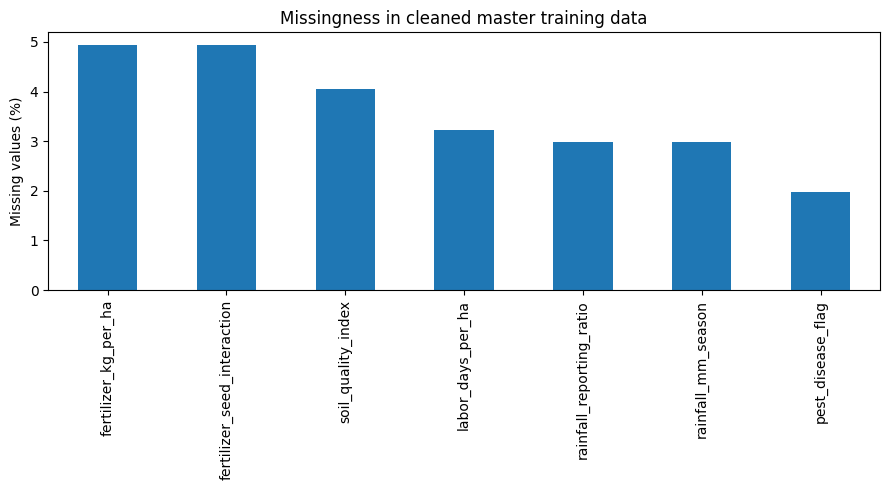

In [2]:
# Figure 01 — Missingness overview.
missing = train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(9,5))
missing.mul(100).plot(kind="bar")
plt.ylabel("Missing values (%)")
plt.title("Missingness in cleaned master training data")
savefig("fig01_missingness.png")

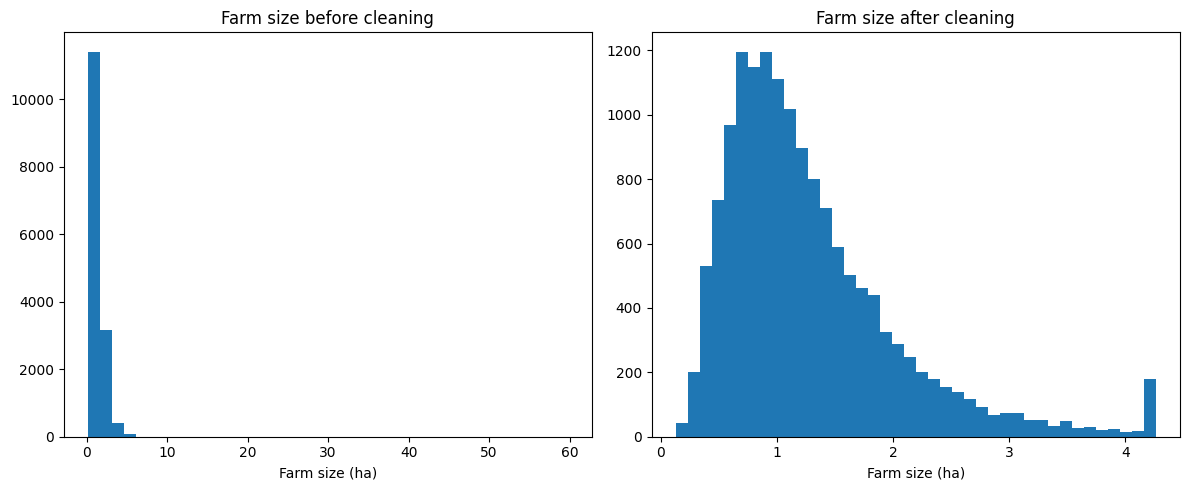

In [3]:
# Figure 02 — Before/after cleaning: key numeric distributions.
raw = pd.read_csv(ROOT / "data/raw/crop_yield_train.csv")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(raw["farm_size_ha"].dropna(), bins=40)
axes[0].set_title("Farm size before cleaning")
axes[0].set_xlabel("Farm size (ha)")

axes[1].hist(train["farm_size_ha"].dropna(), bins=40)
axes[1].set_title("Farm size after cleaning")
axes[1].set_xlabel("Farm size (ha)")

savefig("fig02_before_after_cleaning.png")

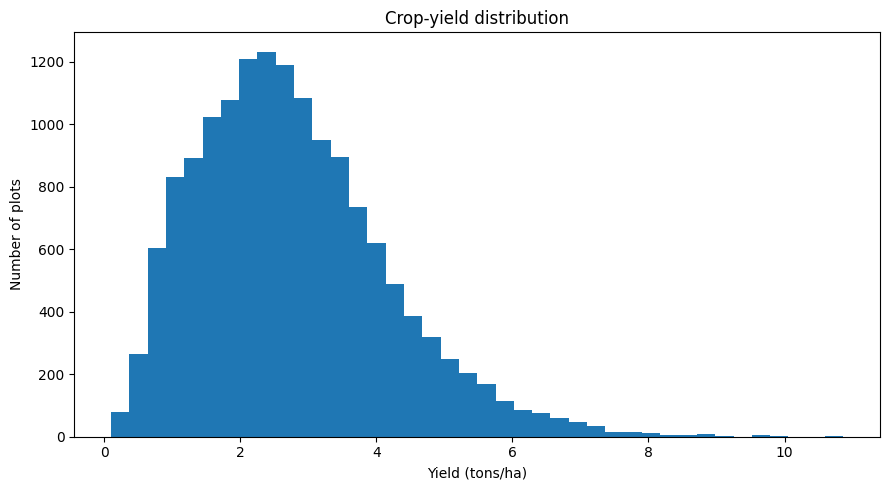

In [4]:
# Figure 03 — Yield distribution.
plt.figure(figsize=(9,5))
plt.hist(train["yield_tons_per_ha"], bins=40)
plt.xlabel("Yield (tons/ha)")
plt.ylabel("Number of plots")
plt.title("Crop-yield distribution")
savefig("fig03_yield_distribution.png")

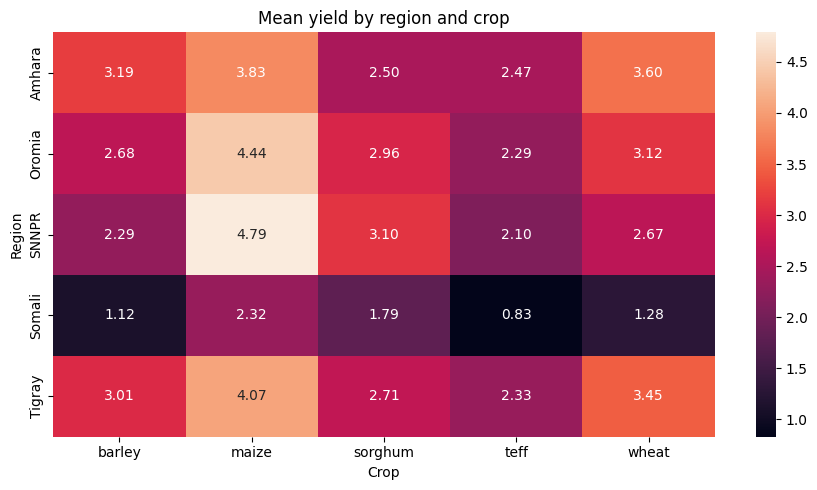

In [5]:
# Figure 04 — Region × crop heatmap.
pivot = train.pivot_table(
    index="region",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Mean yield by region and crop")
plt.xlabel("Crop")
plt.ylabel("Region")
savefig("fig04_region_crop_heatmap.png")

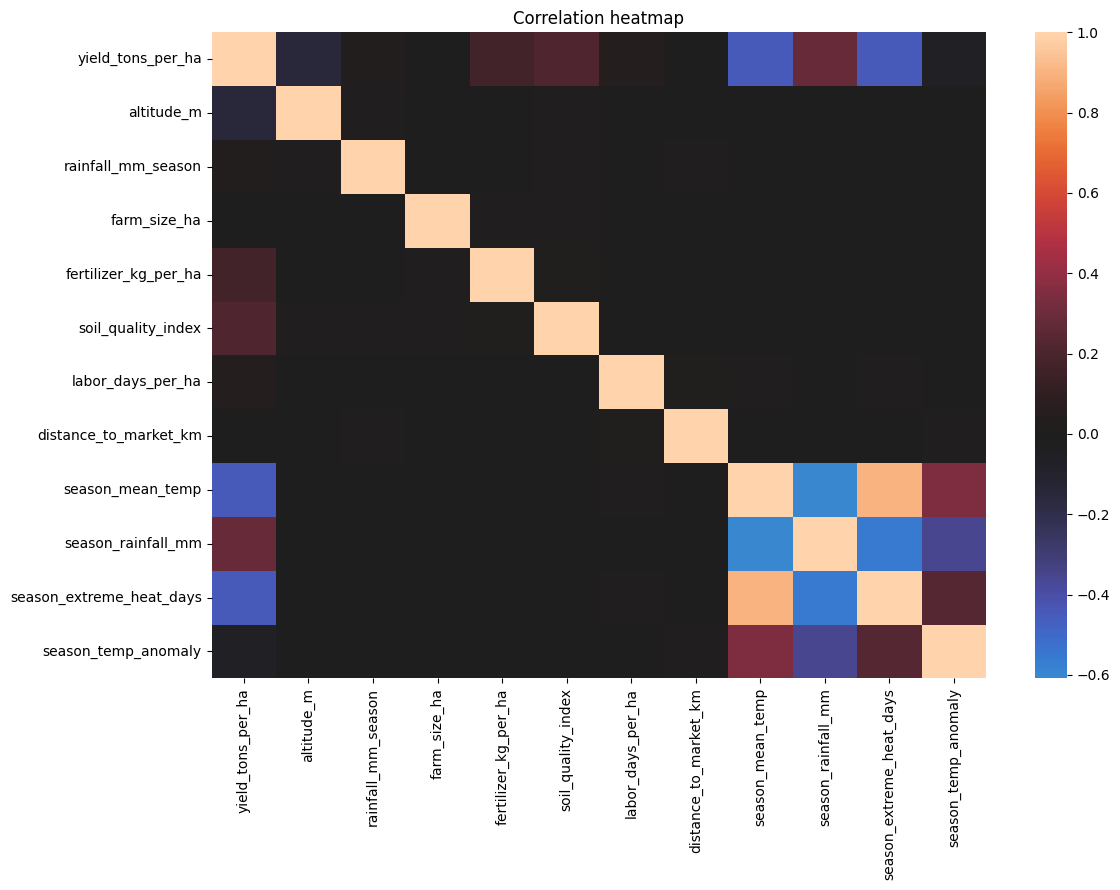

In [6]:
# Figure 05 — Correlation heatmap for important numeric variables.
numeric_cols = [
    "yield_tons_per_ha","altitude_m","rainfall_mm_season",
    "farm_size_ha","fertilizer_kg_per_ha","soil_quality_index",
    "labor_days_per_ha","distance_to_market_km",
    "season_mean_temp","season_rainfall_mm",
    "season_extreme_heat_days","season_temp_anomaly"
]

corr = train[numeric_cols].corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr, cmap=None, center=0)
plt.title("Correlation heatmap")
savefig("fig05_correlation_heatmap.png")

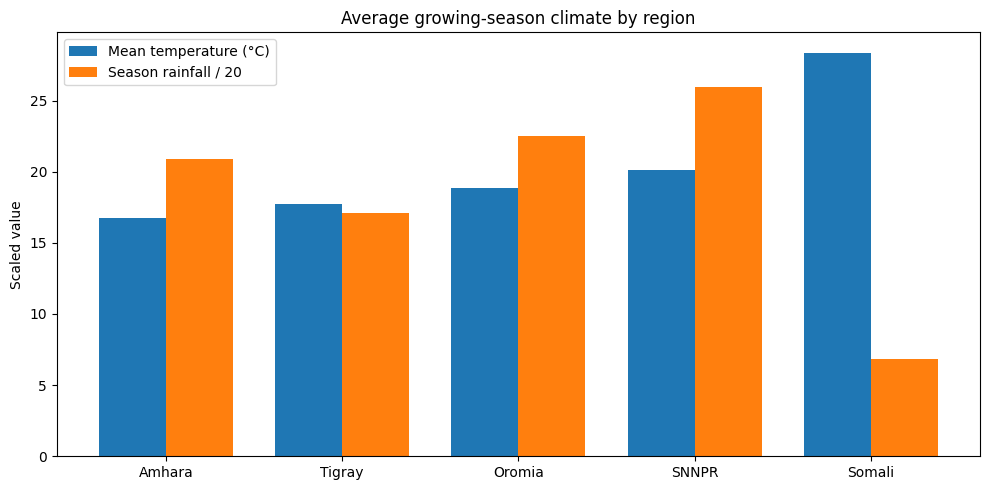

In [7]:
# Figure 06 — Climate by region.
climate = (
    train.groupby("region")[["season_mean_temp","season_rainfall_mm"]]
    .mean()
    .sort_values("season_mean_temp")
)

plt.figure(figsize=(10,5))
x = np.arange(len(climate))
width = 0.38
plt.bar(x - width/2, climate["season_mean_temp"], width, label="Mean temperature (°C)")
plt.bar(x + width/2, climate["season_rainfall_mm"] / 20, width, label="Season rainfall / 20")
plt.xticks(x, climate.index)
plt.ylabel("Scaled value")
plt.title("Average growing-season climate by region")
plt.legend()
savefig("fig06_climate_by_region.png")

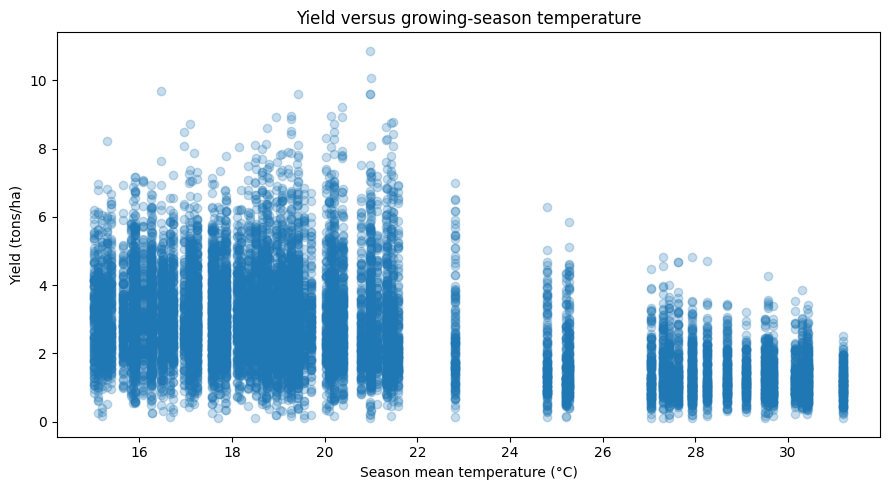

In [8]:
# Figure 07 — Yield versus seasonal temperature.
plt.figure(figsize=(9,5))
plt.scatter(
    train["season_mean_temp"],
    train["yield_tons_per_ha"],
    alpha=0.25
)
plt.xlabel("Season mean temperature (°C)")
plt.ylabel("Yield (tons/ha)")
plt.title("Yield versus growing-season temperature")
savefig("fig07_yield_vs_season_temp.png")

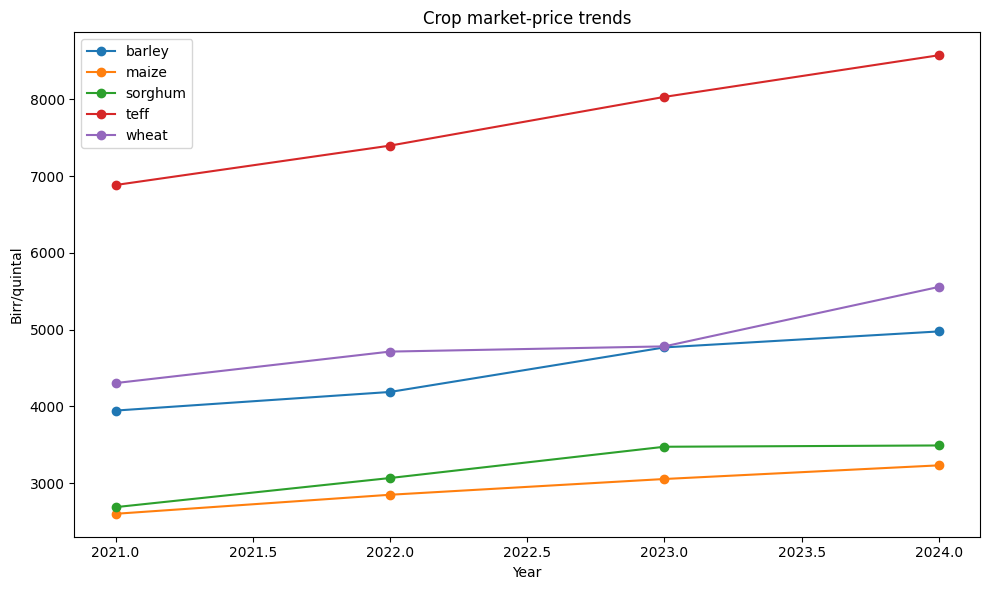

In [9]:
# Figure 08 — Price trends.
price_trend = prices.groupby(["year","crop_type"])["price_birr_per_quintal"].mean().reset_index()

plt.figure(figsize=(10,6))
for crop in sorted(price_trend["crop_type"].unique()):
    d = price_trend[price_trend["crop_type"] == crop]
    plt.plot(d["year"], d["price_birr_per_quintal"], marker="o", label=crop)

plt.xlabel("Year")
plt.ylabel("Birr/quintal")
plt.title("Crop market-price trends")
plt.legend()
savefig("fig08_price_trends.png")

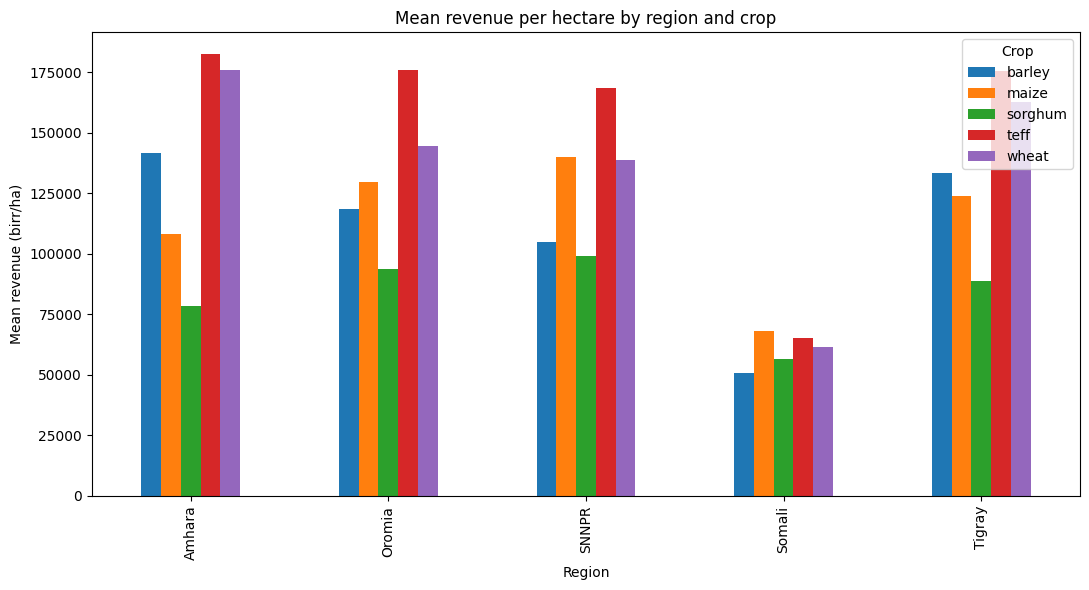

In [10]:
# Figure 09 — Revenue by crop and region.
revenue = (
    analysis.groupby(["region","crop_type"])["revenue_birr_ha"]
    .mean()
    .unstack()
)

plt.figure(figsize=(11,6))
revenue.plot(kind="bar", ax=plt.gca())
plt.ylabel("Mean revenue (birr/ha)")
plt.xlabel("Region")
plt.title("Mean revenue per hectare by region and crop")
plt.legend(title="Crop")
savefig("fig09_revenue_by_crop_region.png")

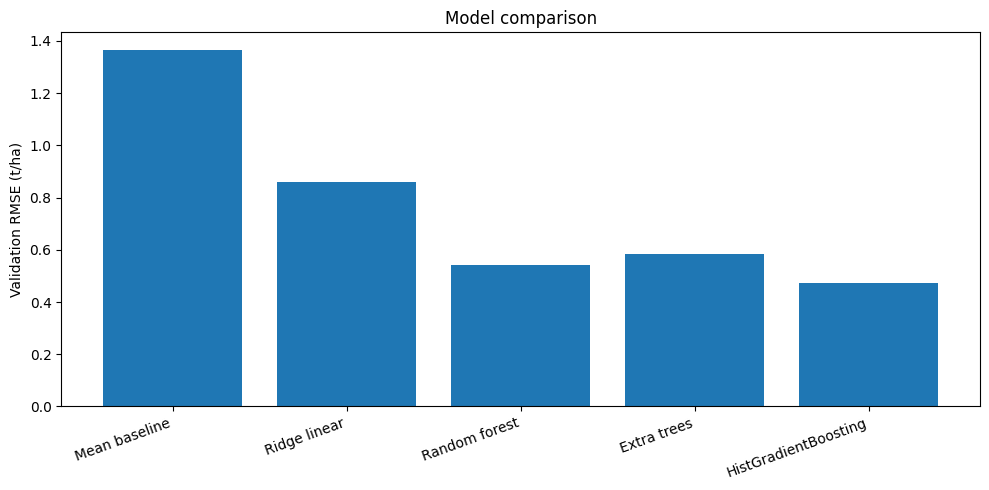

In [11]:
# Figure 10 — Model comparison.
model_file = REPORTS / "model_comparison.csv"
if model_file.exists():
    model_comp = pd.read_csv(model_file)
else:
    model_comp = pd.DataFrame({
        "model":["Mean baseline","Ridge linear","Random forest","Extra trees","HistGradientBoosting"],
        "RMSE":[1.3649,0.860652,0.540823,0.583382,0.473845]
    })

plt.figure(figsize=(10,5))
plt.bar(model_comp["model"], model_comp["RMSE"])
plt.ylabel("Validation RMSE (t/ha)")
plt.title("Model comparison")
plt.xticks(rotation=20, ha="right")
savefig("fig10_model_comparison.png")

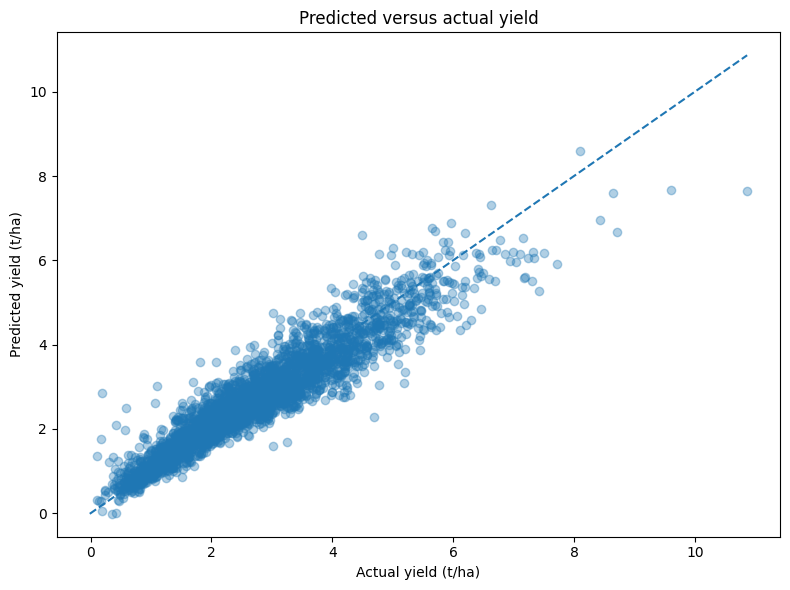

In [12]:
# Figure 11 — Predicted versus actual and residuals.
pred_file = REPORTS / "validation_predictions_transparent.csv"

if pred_file.exists():
    pred = pd.read_csv(pred_file)
    residual = pred["actual"] - pred["predicted"]
    plt.figure(figsize=(8,6))
    plt.scatter(pred["actual"], pred["predicted"], alpha=0.35)
    lims = [
        min(pred["actual"].min(), pred["predicted"].min()),
        max(pred["actual"].max(), pred["predicted"].max())
    ]
    plt.plot(lims, lims, linestyle="--")
    plt.xlabel("Actual yield (t/ha)")
    plt.ylabel("Predicted yield (t/ha)")
    plt.title("Predicted versus actual yield")
else:
    # The modeling notebook creates the prediction file.
    # This fallback still makes the notebook executable if run before D.
    plt.text(0.5,0.5,"Run Notebook 04 first to create validation_predictions_transparent.csv",
             ha="center", va="center")
    plt.axis("off")

savefig("fig11_predicted_vs_actual_residuals.png")

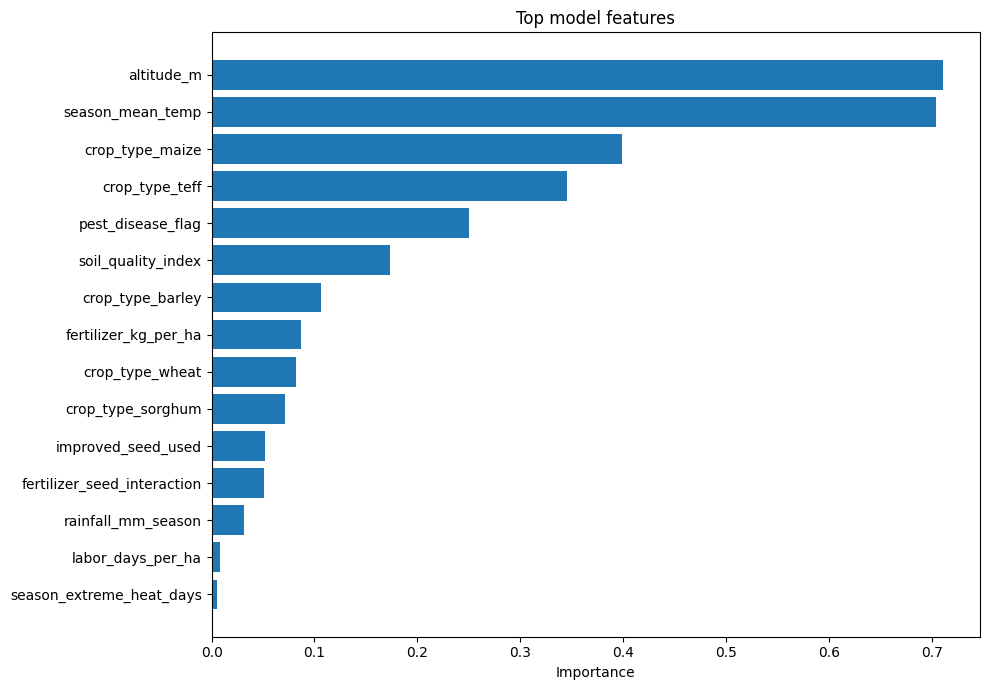

In [13]:
# Figure 12 — Feature importance.
importance_file = REPORTS / "feature_importance.csv"

if importance_file.exists():
    imp = pd.read_csv(importance_file)
    importance_col = "importance" if "importance" in imp.columns else "importance_mean"
    imp = imp.rename(columns={importance_col:"importance"}).sort_values("importance", ascending=False).head(15)
else:
    imp = pd.DataFrame({"feature":[],"importance":[]})

plt.figure(figsize=(10,7))
if len(imp):
    plt.barh(imp["feature"][::-1], imp["importance"][::-1])
    plt.xlabel("Importance")
    plt.title("Top model features")
else:
    plt.text(0.5,0.5,"Run Notebook 04 first to create feature_importance.csv",
             ha="center", va="center")
    plt.axis("off")

savefig("fig12_feature_importance.png")

In [14]:
# Figure captions / interpretation notes.
captions = {
    "fig01_missingness.png":"Missingness after data cleaning. Remaining missing values are handled by model-side imputation.",
    "fig02_before_after_cleaning.png":"Farm-size distribution before and after train-derived capping of extreme values.",
    "fig03_yield_distribution.png":"Distribution of plot-level crop yield in tons per hectare.",
    "fig04_region_crop_heatmap.png":"Mean yield for each region and crop combination.",
    "fig05_correlation_heatmap.png":"Pairwise correlations among key numeric agricultural and weather variables.",
    "fig06_climate_by_region.png":"Average growing-season climate by region; rainfall is scaled for visual comparison.",
    "fig07_yield_vs_season_temp.png":"Relationship between seasonal mean temperature and yield; this is descriptive, not causal.",
    "fig08_price_trends.png":"Average market price per quintal by crop and year.",
    "fig09_revenue_by_crop_region.png":"Estimated mean revenue per hectare from yield × 10 × price.",
    "fig10_model_comparison.png":"Validation RMSE comparison across baseline and candidate models.",
    "fig11_predicted_vs_actual_residuals.png":"Validation predictions compared with observed yield.",
    "fig12_feature_importance.png":"Top features used by the final tree-based model."
}

with open(FIGURES / "figure_captions_transparent.md","w",encoding="utf-8") as f:
    for name, caption in captions.items():
        f.write(f"## {name}\n{caption}\n\n")

print("Generated visualization notebook code for all 12 figures.")

Generated visualization notebook code for all 12 figures.
